# THỰC HÀNH 03: PHÁT HIỆN ĐỐI TƯỢNG (OBJECT DETECTION) VỚI YOLO VÀ DETR.

## Thông tin chung

Bài thực hành thuộc môn **Thị Giác Máy Tính Nâng Cao** (*Advanced Computer Vision - K35 - HCMUS*).

- Thành viên nhóm:
  - Nguyễn Trọng Hiếu – 25C11042 (Nhóm trưởng)
  - Trương Lê Bảo Trân – 25C11071
- Giảng viên hướng dẫn: ThS. Nguyễn Mạnh Hùng

## Mục tiêu

- Tìm hiểu mô hình YOLOv8.
- Huấn luyện mô hình trên tập dữ liệu Safety Helmet.
- Đánh giá hiệu năng mô hình.
- Thực hiện suy luận trên dữ liệu kiểm thử.


Trong bài thực hành này sử dụng YOLOv8 của Ultralytics để nhận diện
mũ bảo hộ lao động trên tập dữ liệu Safety Helmet Dataset.

## Nguồn dữ liệu

Bộ dữ liệu được sử dụng trong bài thực hành là **Safety Helmet Dataset**, được công bố trên nền tảng Roboflow Universe. Bộ dữ liệu bao gồm các ảnh chứa người lao động trong môi trường xây dựng cùng với các nhãn đối tượng Helmet, Head và Person phục vụ cho bài toán phát hiện đối tượng (Object Detection).

Nguồn dữ liệu gốc được truy cập tại:

https://universe.roboflow.com/augmented-startups/safety-helmet-dataset-uvh1t


### 1. Kiểm tra môi trường Colab

In [6]:
import tensorflow as tf
print(tf.test.gpu_device_name())

from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

!cat /proc/meminfo

/device:GPU:0
[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 6569929937973558517
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 14426112000
locality {
  bus_id: 1
  links {
  }
}
incarnation: 2730442371668523301
physical_device_desc: "device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5"
xla_global_id: 416903419
]
MemTotal:       13286944 kB
MemFree:         7652212 kB
MemAvailable:   11526440 kB
Buffers:          128664 kB
Cached:          3951400 kB
SwapCached:            0 kB
Active:           628088 kB
Inactive:        4607436 kB
Active(anon):       1556 kB
Inactive(anon):  1166360 kB
Active(file):     626532 kB
Inactive(file):  3441076 kB
Unevictable:          20 kB
Mlocked:              20 kB
SwapTotal:             0 kB
SwapFree:              0 kB
Dirty:               940 kB
Writeback:             0 kB
AnonPages:       1152860 kB
Mapped:          1150016 kB
Shmem:             12444 kB

In [7]:
import torch

print(torch.cuda.current_device())
print(torch.cuda.device(0))
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))
print(torch.cuda.is_available())

# setting device on GPU if available, else CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print()

# additional info when using cuda
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_cached(0)/1024**3,1), 'GB')

0
1
Tesla T4
True
Using device: cuda

Tesla T4
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


/tmp/ipykernel_1050/2566200736.py:19: FutureWarning: `torch.cuda.memory_cached` has been renamed to `torch.cuda.memory_reserved`
  print('Cached:   ', round(torch.cuda.memory_cached(0)/1024**3,1), 'GB')


### 2. Kết nối Google Drive

In [8]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


### 3. Cài đặt YOLOv8

In [ ]:
# Cài đặt thư viện Ultralytics YOLOv8
# và nạp các thành phần cần thiết cho bài toán Object Detection.

%cd /content

!pip install -q ultralytics

from ultralytics import YOLO

print("YOLOv8 ready")

/content
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8 ready


### 4. Tải và chuẩn bị tập dữ liệu

Dataset: Safety Helmet Dataset



In [ ]:
# Kiểm tra sự tồn tại của bộ dữ liệu.
# Nếu chưa có, tự động tải từ Google Drive và giải nén vào môi trường làm việc.

import os

DATASET_DIR = "/content/safety-helmet-dataset.v1i.yolov8"

if not os.path.exists(DATASET_DIR):
    print("Downloading dataset...")

    !pip install -q gdown

    GDRIVE_LINK = "https://drive.google.com/file/d/1Ihd1CwR9k3XnLtFl7f2w8fNbKMEmZ7_k/view?usp=sharing"

    !gdown --fuzzy "$GDRIVE_LINK" -O dataset.zip

    !unzip -oq dataset.zip -d /content

    print("Dataset ready!")
else:
    print("Dataset already exists!")

Downloading...
From (original): https://drive.google.com/uc?id=1Ihd1CwR9k3XnLtFl7f2w8fNbKMEmZ7_k
From (redirected): https://drive.google.com/uc?id=1Ihd1CwR9k3XnLtFl7f2w8fNbKMEmZ7_k&confirm=t&uuid=f141458e-213e-41e7-baf9-e79586da4c0b
To: /content/dataset.zip
100% 33.5M/33.5M [00:01<00:00, 26.0MB/s]
Dataset ready!


### 5. Huấn luyện mô hình

In [ ]:
# Khởi tạo mô hình YOLOv8s với trọng số pretrained trên COCO.
# Thực hiện fine-tuning trên bộ dữ liệu Safety Helmet
# nhằm học đặc trưng của các lớp Person, Head và Helmet.

from ultralytics import YOLO

model = YOLO("yolov8s.pt")

results = model.train(
    data="/content/safety-helmet-dataset.v1i.yolov8/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,
    project="helmet_project",
    name="yolov8s_helmet"
)

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/safety-helmet-dataset.v1i.yolov8/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_helmet, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, 

Nhận xét:
Sau khi lựa chọn mô hình tốt nhất tại epoch 56, nhóm tiến hành đánh giá lại trên tập Validation. Kết quả cho thấy mô hình đạt Precision = 0,859, Recall = 0,835, mAP@0.5 = 0,889 và mAP@0.5:0.95 = 0,454. Trong ba lớp đối tượng, lớp Helmet đạt hiệu năng cao nhất với mAP@0.5 bằng 0,938, trong khi lớp Head có kết quả thấp hơn do số lượng mẫu ít hơn và kích thước đối tượng nhỏ. Kết quả này cho thấy mô hình có khả năng phát hiện đối tượng ổn định và đạt độ chính xác cao trên tập Validation.

### 6. Trực quan hóa kết quả huấn luyện

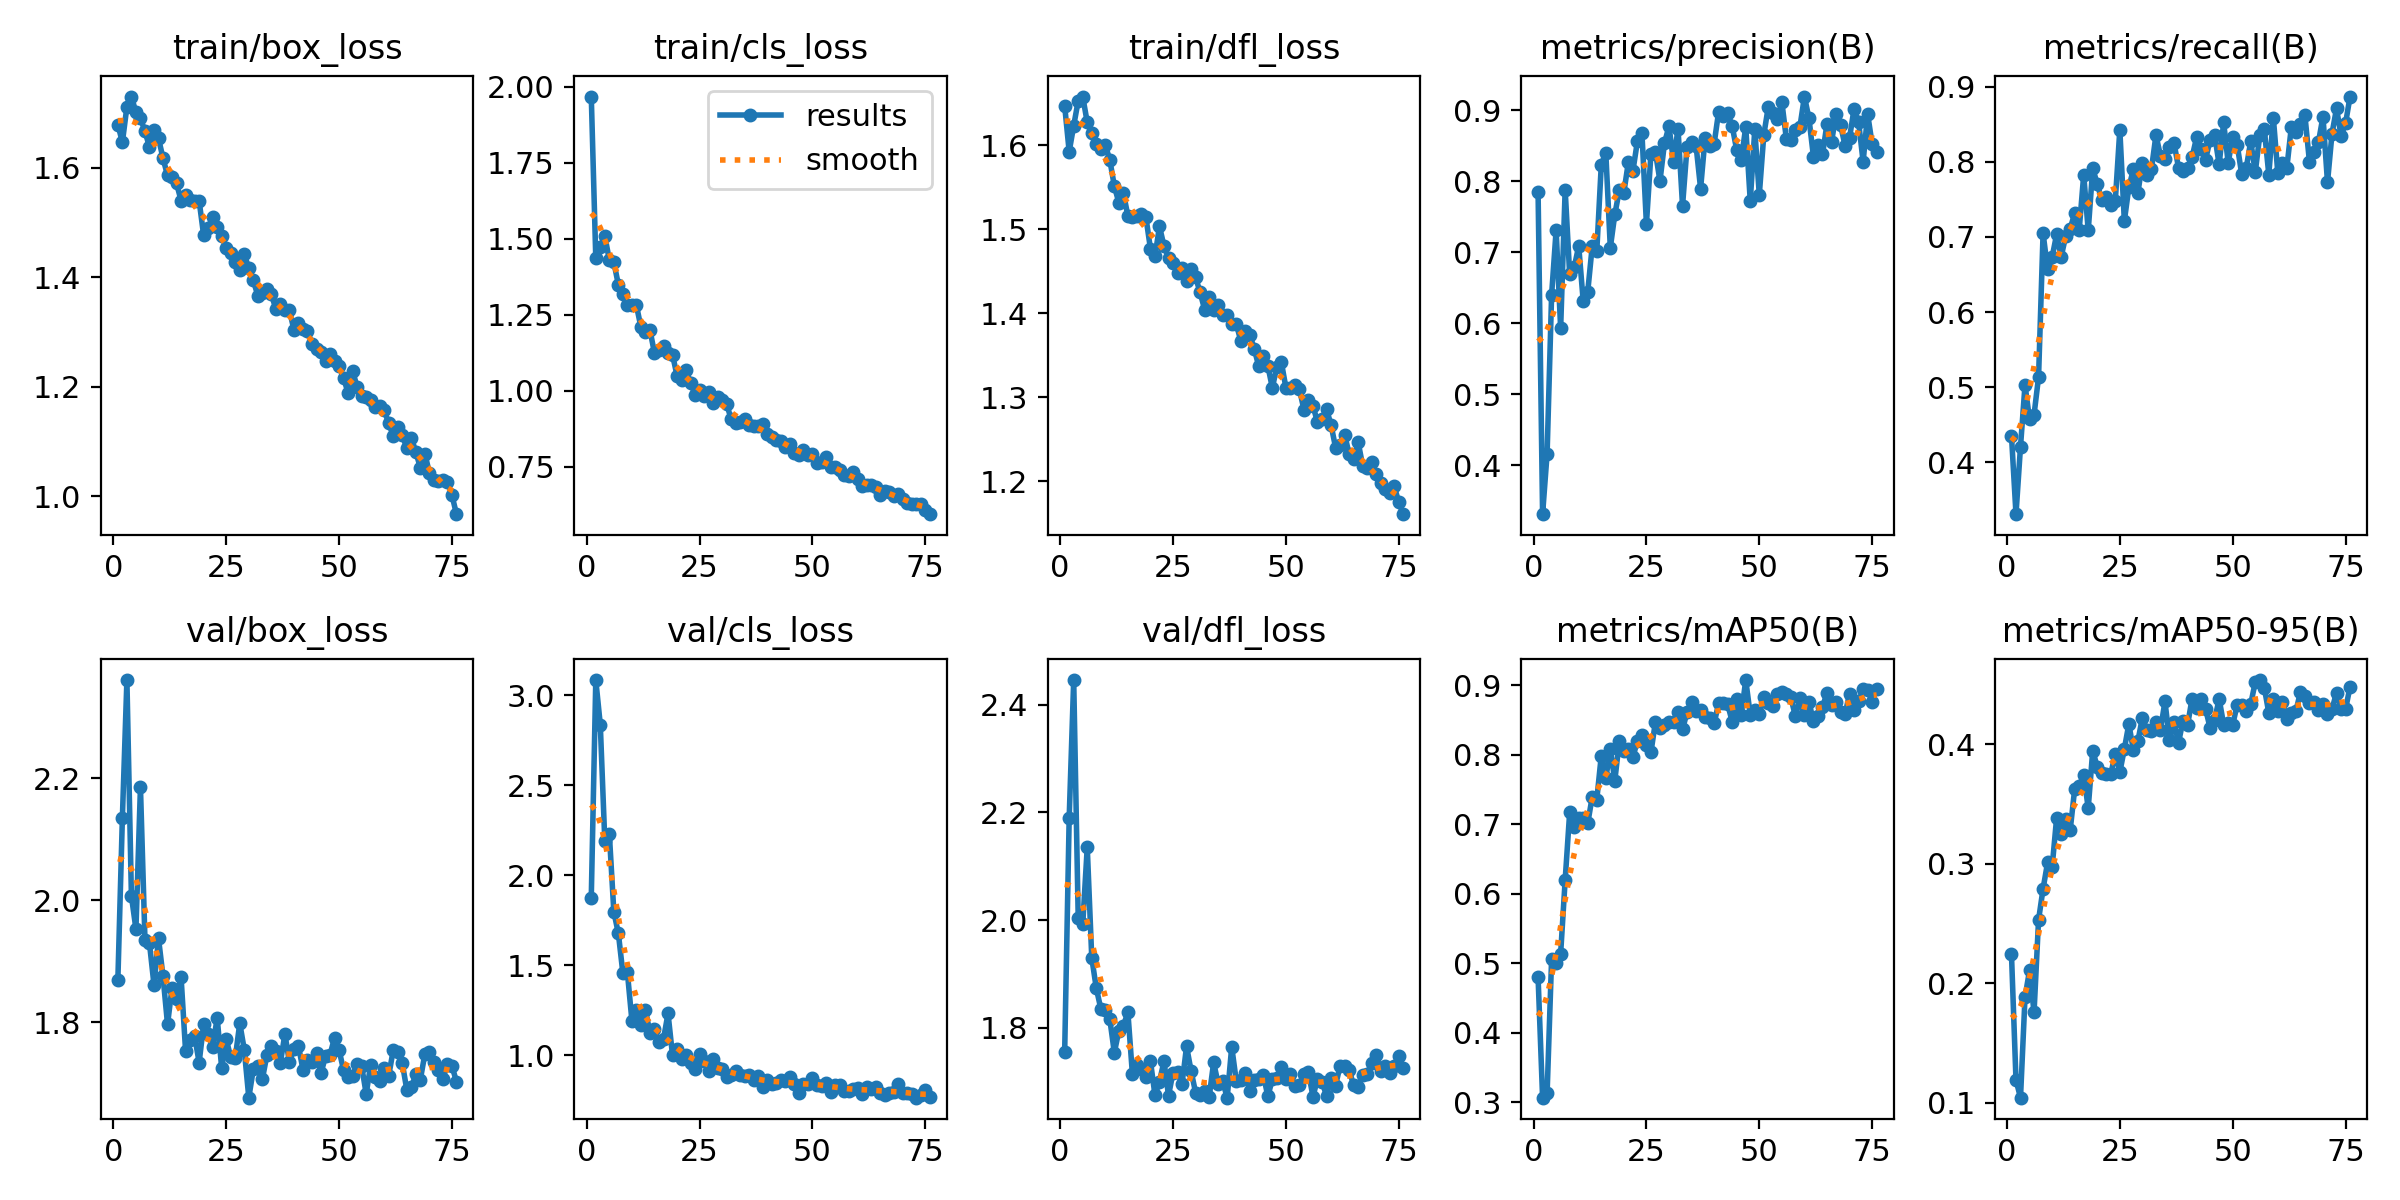

In [ ]:
# Learning Curve
# Hiển thị Learning Curve để theo dõi sự thay đổi
# của Loss, Precision, Recall và mAP trong quá trình huấn luyện.

from IPython.display import Image

Image("/content/runs/detect/helmet_project/yolov8s_helmet/results.png")

#### Nhận xét

Nhận xét: Các giá trị train loss và validation loss đều giảm dần theo số epoch, cho thấy mô hình học được các đặc trưng của dữ liệu và quá trình huấn luyện diễn ra ổn định. Đồng thời, các chỉ số Precision, Recall, mAP@0.5 và mAP@0.5:0.95 tăng nhanh trong giai đoạn đầu và dần hội tụ ở các epoch cuối. Kết quả này cho thấy mô hình YOLOv8 đã hội tụ tốt và đạt hiệu năng ổn định trên bộ dữ liệu Safety Helmet Detection.

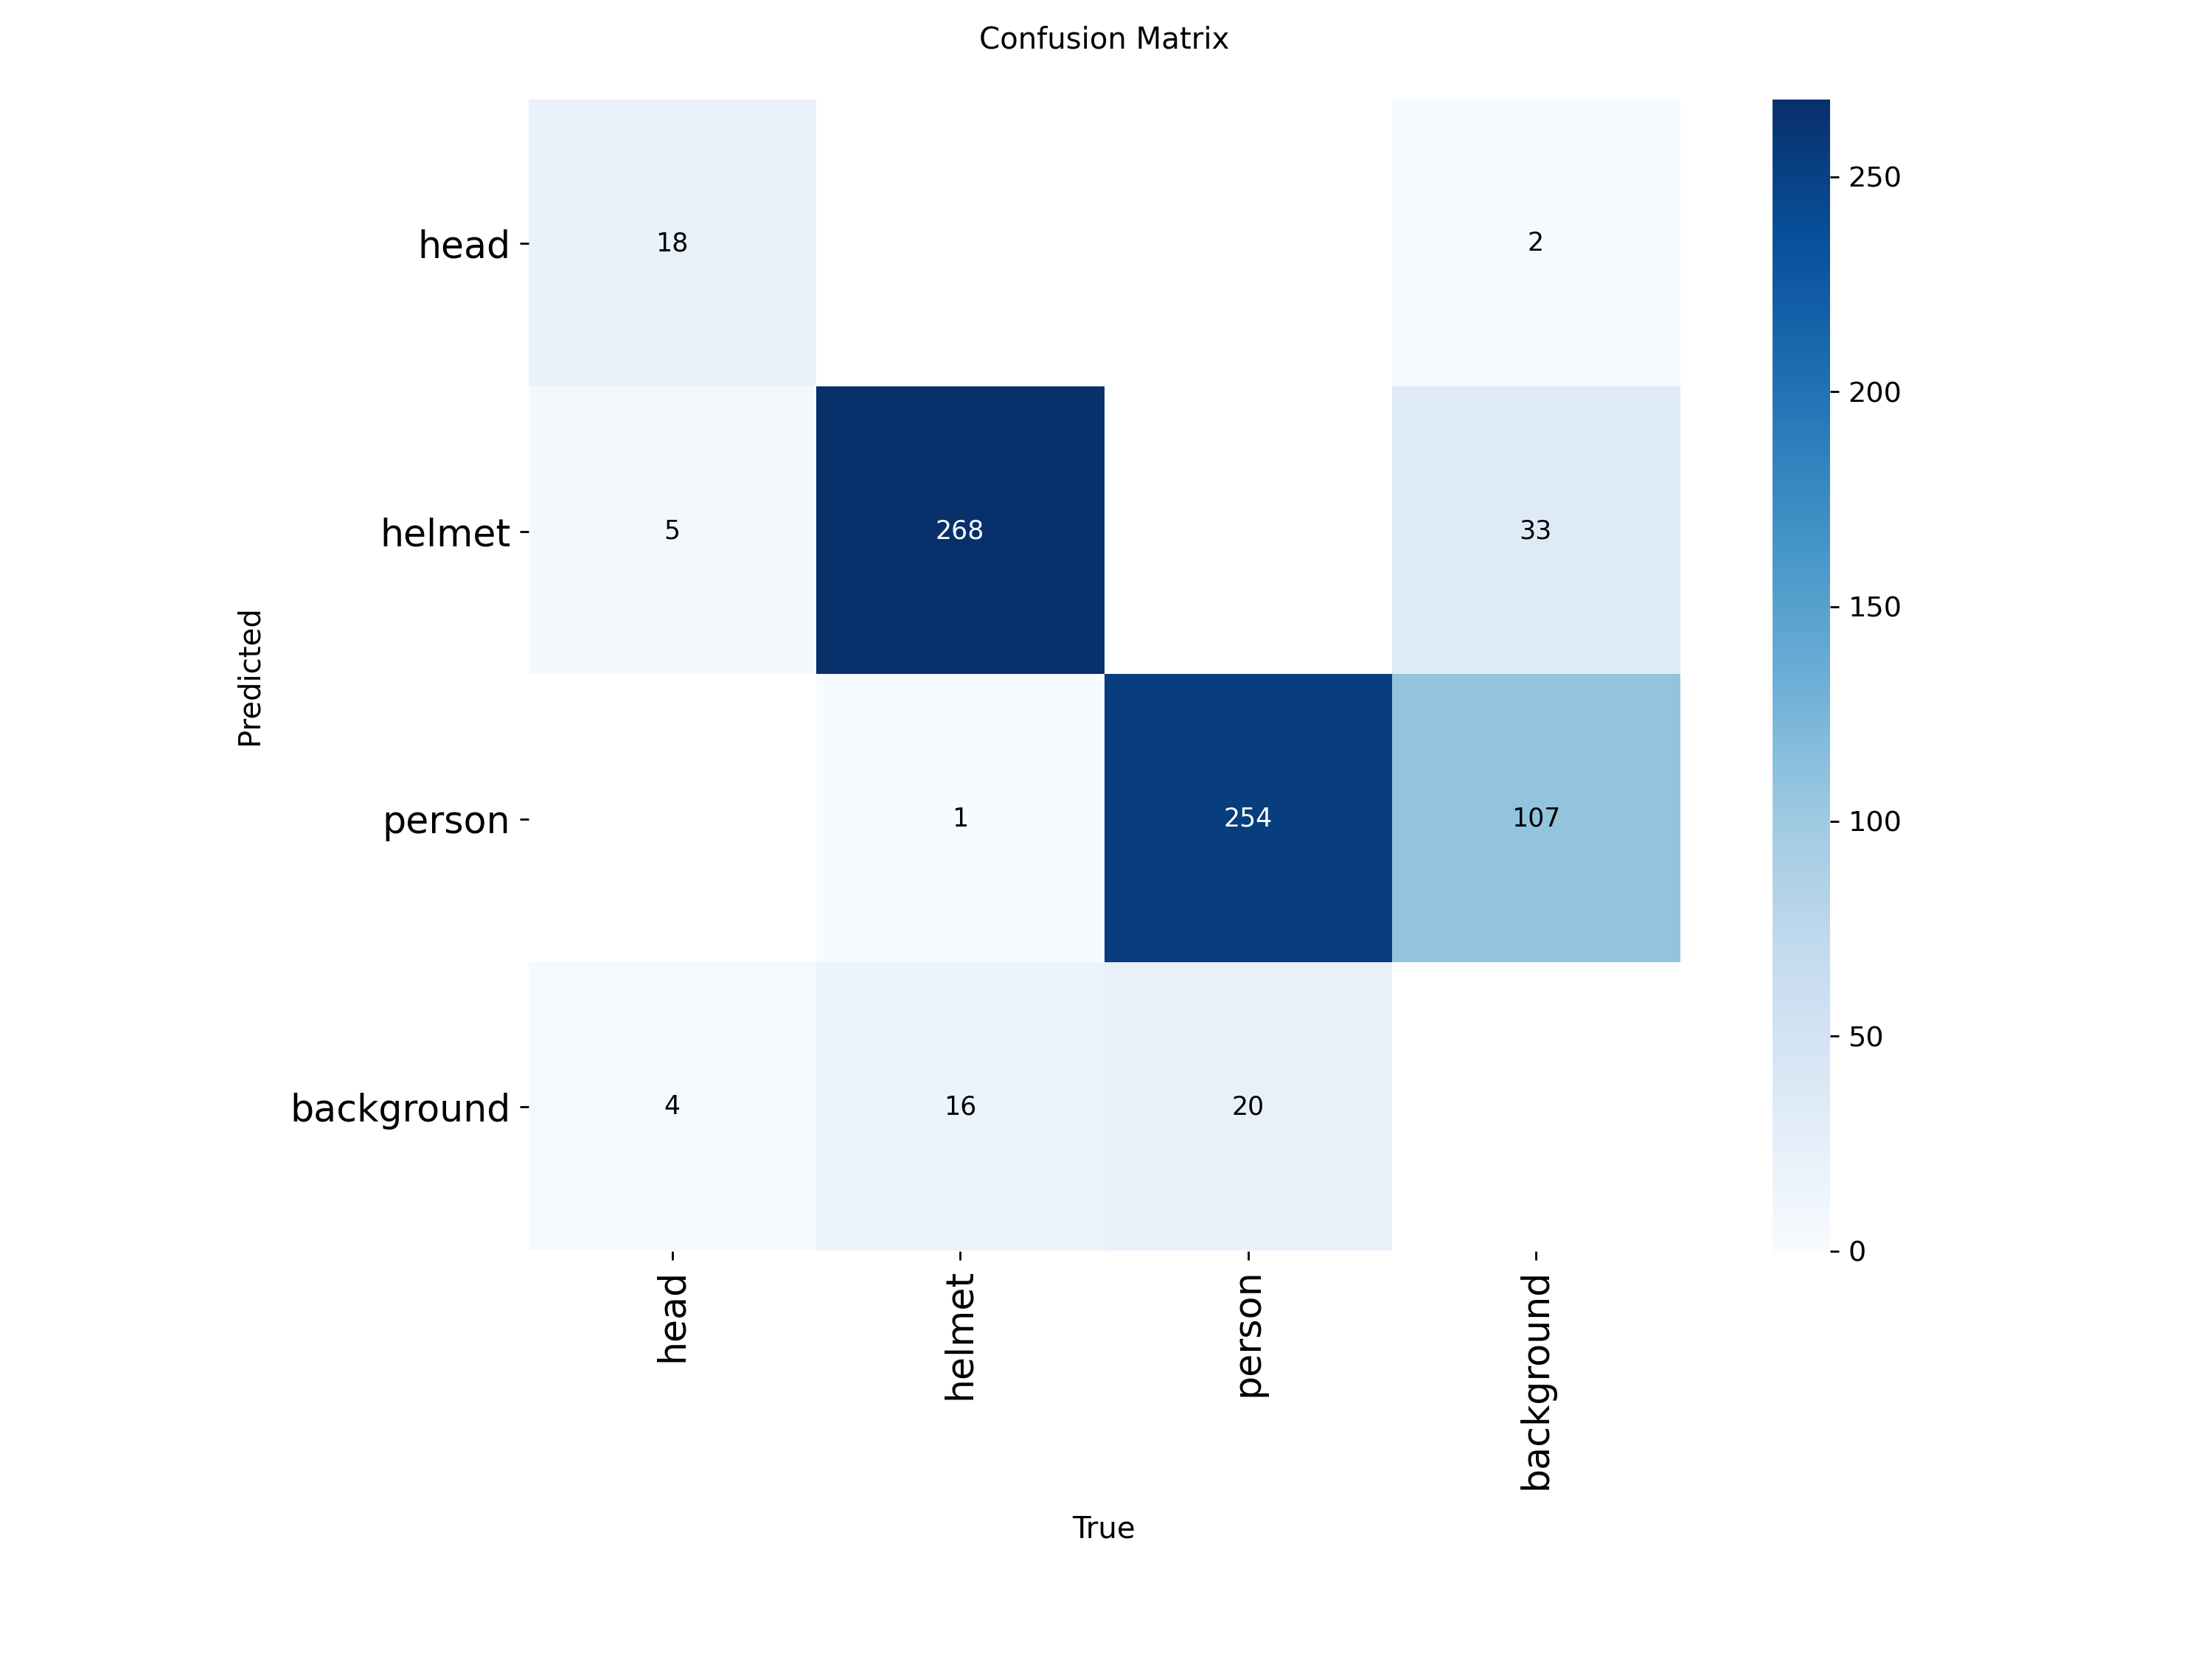

In [ ]:
# Confusion Matrix
# Trực quan hóa Confusion Matrix nhằm đánh giá
# mức độ phân biệt giữa các lớp đối tượng của mô hình.

from IPython.display import Image

Image("/content/runs/detect/helmet_project/yolov8s_helmet/confusion_matrix.png")

Nhận xét:
Ma trận nhầm lẫn cho thấy phần lớn các dự đoán đúng nằm trên đường chéo chính, chứng tỏ mô hình có khả năng phân biệt tốt giữa ba lớp Head, Helmet và Person. Trong đó, lớp Helmet và Person đạt số lượng dự đoán đúng cao nhất với lần lượt 268 và 254 đối tượng được nhận diện chính xác. Một số đối tượng bị bỏ sót và được gán vào lớp background, chủ yếu do kích thước nhỏ, bị che khuất hoặc điều kiện hình ảnh không thuận lợi. Nhìn chung, kết quả cho thấy mô hình YOLOv8 đạt hiệu năng phát hiện đối tượng tốt trên bộ dữ liệu Safety Helmet Detection.

### 7. Đánh giá mô hình tốt nhất trên tập Test

In [ ]:
# Nạp mô hình tốt nhất (best.pt) và đánh giá
# trên tập test độc lập để thu thập các chỉ số Precision,
# Recall, mAP50 và mAP50-95.

from ultralytics import YOLO

best_model = YOLO(
    "/content/runs/detect/helmet_project/yolov8s_helmet/weights/best.pt"
)

metrics = best_model.val(
    data="/content/safety-helmet-dataset.v1i.yolov8/data.yaml",
    split="test"
)

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 7.0±3.1 MB/s, size: 29.6 KB)
val: Scanning /content/safety-helmet-dataset.v1i.yolov8/test/labels... 109 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 109/109 1.2Kit/s 0.1s
val: New cache created: /content/safety-helmet-dataset.v1i.yolov8/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.1it/s 6.1s
                   all        109        320      0.836      0.846      0.887      0.467
                  head         12         16      0.912       0.75      0.912      0.486
                helmet         98        162      0.898      0.914      0.944      0.464
                person         78        142      0.698      0.873      0.805      0.451
Speed: 10.6ms preprocess, 15.3ms inference

Nhận xét:
Trên tập Test gồm 109 ảnh và 320 đối tượng, mô hình YOLOv8 đạt Precision = 0,836, Recall = 0,846, mAP@0.5 = 0,887 và mAP@0.5:0.95 = 0,467. Kết quả cho thấy mô hình có khả năng tổng quát hóa tốt trên dữ liệu chưa xuất hiện trong quá trình huấn luyện. Trong ba lớp đối tượng, lớp Helmet đạt kết quả cao nhất với mAP@0.5 đạt 0,944, trong khi lớp Person có độ chính xác thấp hơn do kích thước và hình dạng đối tượng đa dạng hơn.

### 8. Dự đoán trên ảnh thử nghiệm

In [ ]:
# Thực hiện suy luận trên tập ảnh test
# bằng mô hình đã huấn luyện và lưu kết quả dự đoán.

best_model.predict(
    source="/content/safety-helmet-dataset.v1i.yolov8/test/images",
    save=True,
    conf=0.25
)


image 1/109 /content/safety-helmet-dataset.v1i.yolov8/test/images/helmet-10-_jpg.rf.eee985865a1a52407316f0c9ea7a9b3e.jpg: 640x640 1 head, 2 helmets, 2 persons, 26.2ms
image 2/109 /content/safety-helmet-dataset.v1i.yolov8/test/images/helmet-108-_jpg.rf.85e7ccb9c8c26013fe9016001b68fc72.jpg: 640x640 1 helmet, 2 persons, 15.9ms
image 3/109 /content/safety-helmet-dataset.v1i.yolov8/test/images/helmet-110-_jpg.rf.b9d38442adb18ac5188cee9ef27392d5.jpg: 640x640 1 helmet, 1 person, 15.9ms
image 4/109 /content/safety-helmet-dataset.v1i.yolov8/test/images/helmet-12-_jpg.rf.e060b7cfb30b033ca50fc1b9ed48efe7.jpg: 640x640 2 helmets, 3 persons, 15.8ms
image 5/109 /content/safety-helmet-dataset.v1i.yolov8/test/images/helmet-135-_jpg.rf.d94276d795b6dc4edc5b3caa89b73b8a.jpg: 640x640 1 helmet, 2 persons, 15.8ms
image 6/109 /content/safety-helmet-dataset.v1i.yolov8/test/images/helmet-136-_jpg.rf.167f996a6fc4e10c7884f5b3e7e65be3.jpg: 640x640 2 helmets, 3 persons, 15.8ms
image 7/109 /content/safety-helmet-da

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'head', 1: 'helmet', 2: 'person'}
 obb: None
 orig_img: array([[[248, 237, 223],
         [248, 237, 223],
         [248, 237, 223],
         ...,
         [246, 238, 221],
         [246, 238, 221],
         [246, 238, 221]],
 
        [[248, 237, 223],
         [248, 237, 223],
         [248, 237, 223],
         ...,
         [246, 238, 221],
         [246, 238, 221],
         [246, 238, 221]],
 
        [[248, 237, 223],
         [248, 237, 223],
         [248, 237, 223],
         ...,
         [246, 238, 221],
         [246, 238, 221],
         [246, 238, 221]],
 
        ...,
 
        [[ 47,  48,  62],
         [ 31,  37,  50],
         [ 34,  43,  56],
         ...,
         [ 82,  84, 102],
         [ 77,  79,  97],
         [ 77,  79,  97]],
 
        [[ 53,  53,  67],
         [ 36,  39,  53],
         [ 36,  45,  55],
        

Prediction folder: runs/detect/predict
Number of images: 109
Selected: person-356-_jpg.rf.c82076db246062cd51770faa5795d99e.jpg


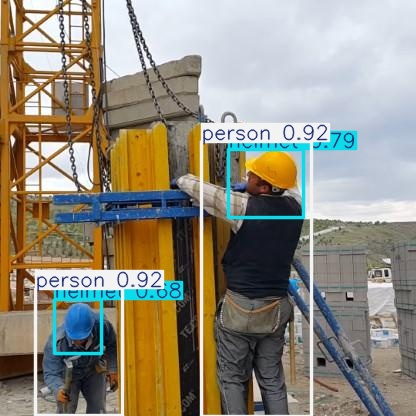

In [ ]:
# Chọn ngẫu nhiên một ảnh dự đoán để kiểm tra trực quan
# chất lượng phát hiện đối tượng của mô hình.

from IPython.display import Image, display
import glob
import os
import random

pred_dir = sorted(
    glob.glob("runs/detect/predict*")
)[-1]

print("Prediction folder:", pred_dir)

images = glob.glob(
    os.path.join(pred_dir, "*.jpg")
)

print("Number of images:", len(images))

random_img = random.choice(images)

print("Selected:", os.path.basename(random_img))

display(
    Image(
        filename=random_img,
        width=800
    )
)

### 9. Lưu mô hình tốt nhất vào Google Drive

In [33]:
!cp \
"/content/runs/detect/helmet_project/yolov8s_helmet/weights/best.pt" \
"/content/gdrive/MyDrive/best_helmet_yolov8.pt"

### 10. Nhận xét và kết luận

#### **Kết quả đạt được:**

Huấn luyện thành công mô hình YOLOv8 trên bộ dữ liệu Safety Helmet Detection.

Mô hình nhận diện được ba lớp đối tượng gồm Head, Helmet và Person.

Mô hình đạt kết quả tốt trên tập Test với:
Precision: 0,836

Recall: 0,846

mAP@0.5: 0,887

mAP@0.5:0.95: 0,467

Các bounding box được dự đoán tương đối chính xác và bám sát vị trí đối tượng thực tế.

Quá trình huấn luyện hội tụ ổn định và mô hình không xuất hiện dấu hiệu overfitting nghiêm trọng.

#### **Ưu điểm:**

Tốc độ huấn luyện và suy luận nhanh.

Dễ triển khai trên các hệ thống thực tế.

Đạt độ chính xác cao đối với bài toán phát hiện mũ bảo hộ.

#### **Nhược điểm:**

Hiệu quả phát hiện phụ thuộc vào chất lượng và sự đa dạng của dữ liệu huấn luyện.

Độ chính xác giảm đối với các đối tượng nhỏ, bị che khuất hoặc xuất hiện trong điều kiện ánh sáng không thuận lợi